### 2. a

$R_{X,d}$ retorna o polinômio $q$ que minimiza $||L_X(q) - b||_2^2$.

Como nesse caso $b = L_X(p)$, queremos minimizar $||L_X(q) - L_X(p)||_2^2$. Logo, é trivial notar que a solução é $q = p$.

Como $R_{X,d}(L_X(p)) = p$ concluímos que $R_{X,d} \circ L_X = id_{P_d}$

### 2. b

Sejam $b_1 e b_2$ vetores no $R^m$ e sejam $p_1$ e $p_2$ os polinômios que melhor aproximam $b_1$ e $b_2$ respectivamente. É intuitivo que o polinômio que melhor aproxima $\alpha b_1 + \beta b_2$ seja $\alpha p_1 + \beta p_2$.

Ou seja, $R_{X,d}(\alpha b_1 + \beta b_2) = \alpha R_{X,d}(b_1) + \beta R_{X,d}(b_2) $

### 2. c

Queremos achar o polinômio que melhor aproxima $b$ na base canônica de $P_d$.
Seja $a = [a_0, a_1, ..., a_n]$ o vetor dos coeficientes de $p$, então queremos minimizar $E = ||Va - b||_2^2$. 

Portanto, a solução é a pseudo-inversa $a = (V^TV)^{-1}V^Tb$.

Logo $R_{X,d} = (V^TV)^{-1}V^T$

### 2. d

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def vander_test_fixing_m(m: int, log=False) -> None:
    X = np.linspace(-1,1,m)
    x = np.linspace(2,m,m-1)
    y = []
    for d in range(1, m):
        V = np.vander(X, N=d+1, increasing=True)
        c = np.linalg.cond(V)
        y.append(c)
    plt.plot(x,y)
    plt.xlabel("d")
    plt.ylabel("cond")
    if log:
        plt.yscale("log")


def vander_test_fixing_d(d:int, max_m:int) -> None:
    x = []
    y = []
    for m in range(d+1, max_m+1):
        X = np.linspace(-1,1,m)
        V = np.vander(X,N=d+1,increasing=True)
        c = np.linalg.cond(V)
        x.append(m)
        y.append(c)
    plt.plot(x,y)
    plt.xlabel("m")
    plt.ylabel("cond")

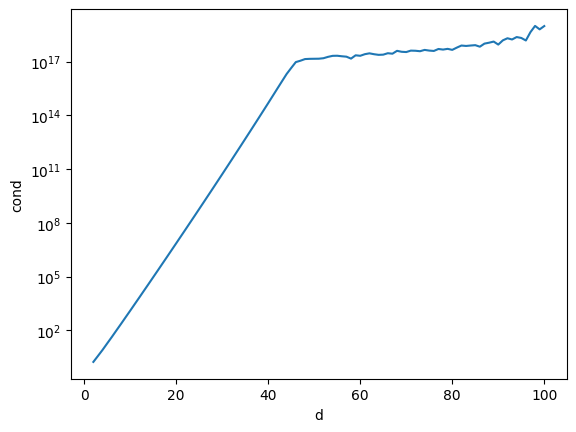

In [3]:
vander_test_fixing_m(100, log=True)

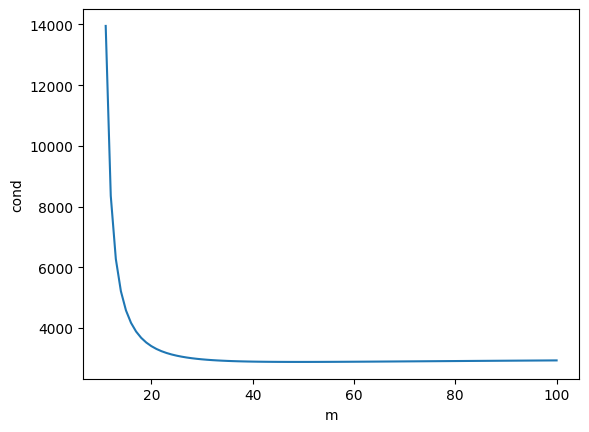

In [4]:
vander_test_fixing_d(10,100)

Como podemos ver, aumentar $d$ com $m$ fixo aumenta drasticamente o condicionamento da matriz, enquanto aumentar $m$ fixando $d$ estabiliza o condicionamento da matriz.

### 2. e

In [14]:
def lagrange_basis(X):
    n = len(X)
    basis = []

    for i in range(n):
        p = np.poly1d([1])

        for j in range(n):
            if j != 1:
                p *= np.poly1d((1, - X[j]) / (X[i] - X[j]))
        basis.append(p)

    return basis